# Compare runs

Loads training histories and saved evaluation results for two or more runs and shows them side by side, plus a representative-predictions gallery per run.

- Training curves come from `logs/<run>/history.json`.
- Comparison table comes from `logs/<run>/config.json` and `artifacts/<run>/evaluation.json`.
- Representative samples (best/median/p90/worst by per-sample MPKE) come from `artifacts/<run>/evaluation.json`.

Per-run evaluation files are produced by `python -m src.evaluation.evaluate_run <run-name>`.

In [15]:
import sys
import json
from pathlib import Path

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import keras
from IPython.display import Markdown, display

from src.data.freihand import (
    FreiHand,
    SPLIT_SEED,
    SPLIT_VALIDATION_FRACTION,
)
from src.evaluation.comparison import (
    format_comparison_markdown,
    load_run_summary,
)
from src.evaluation.metrics import sample_mpke
from src.evaluation.overlays import prediction_grid
from src.evaluation.training_curves import (
    TRAIN_COLOR,
    VAL_COLOR,
    load_history,
)
from src.models.heatmaps import wrap_with_keypoint_decoder

## Pick runs to compare

Edit `RUNS` to include any run that has both a `logs/<run>/history.json` and an `artifacts/<run>/evaluation.json`.

In [16]:
RUNS = ['baseline', 'improved_v1']
METRICS = ('loss', 'mae')

## Training curves

Each column is one run; each row is one metric. Train and validation curves are overlaid per cell.

**Loss and MAE units differ across runs** because the loss functions act on different target spaces:

- The baseline minimizes MSE on `(x, y)` pixel coordinates in the 224-px input space, so its loss is in pixel² units (typically in the hundreds) and its MAE is in pixels.
- The improved heatmap CNN minimizes MSE on Gaussian heatmap values in [0, 1], so its loss and MAE live on the heatmap-value scale (typically 10⁻³ to 10⁻²).

Use these plots to compare convergence *shape* across runs. The directly comparable number is MPKE in the table further down.

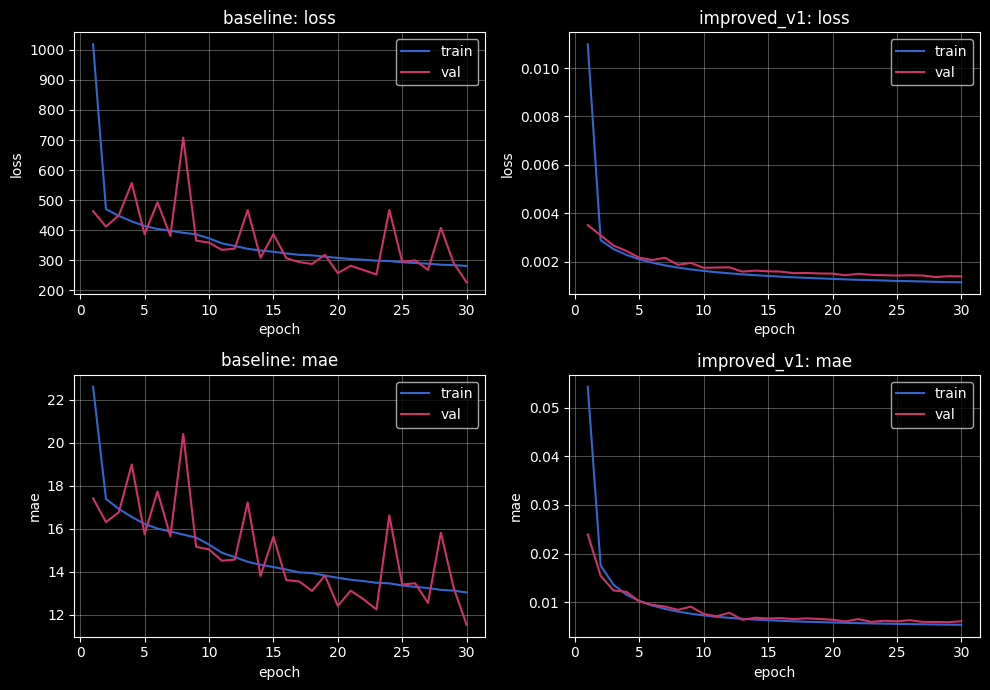

In [17]:
histories = {run: load_history(run) for run in RUNS}

n_rows = len(METRICS)
n_cols = len(RUNS)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.0 * n_cols, 3.5 * n_rows),
    squeeze=False,
)

for col, run in enumerate(RUNS):
    history = histories[run]
    for row, metric in enumerate(METRICS):
        ax = axes[row, col]
        train = history.get(metric)
        val = history.get(f'val_{metric}')
        if train:
            ax.plot(range(1, 1 + len(train)), train, label='train', color=TRAIN_COLOR)
        if val:
            ax.plot(range(1, 1 + len(val)), val, label='val', color=VAL_COLOR)
        ax.set_xlabel('epoch')
        ax.set_ylabel(metric)
        ax.set_title(f'{run}: {metric}')
        ax.grid(True, alpha=0.3)
        if train or val:
            ax.legend()

fig.tight_layout()
plt.show()

## Comparison table

MPKE columns are in pixels at the 224-px input resolution — directly comparable across runs because heatmap predictions are decoded back to keypoint coordinates by `wrap_with_keypoint_decoder` before evaluation.

In [18]:
summaries = [load_run_summary(run) for run in RUNS]
display(Markdown(format_comparison_markdown(summaries)))

| Run         | Model                | Repr.      | Params  | MPKE (px) | Median (px) | p90 (px) | p95 (px) | Max (px) |
| ----------- | -------------------- | ---------- | ------- | --------- | ----------- | -------- | -------- | -------- |
| baseline    | baseline_cnn         | coordinate | 137,962 | 18.10     | 17.22       | 26.32    | 30.06    | 75.99    |
| improved_v1 | residual_heatmap_cnn | heatmap    | 754,229 | 8.59      | 7.43        | 14.30    | 17.36    | 52.44    |

## Representative samples per run

For each run, plot the **best**, **median**, **p90**, and **worst** validation samples by per-sample MPKE. Indices come from `artifacts/<run>/evaluation.json`. Heatmap models are wrapped with `wrap_with_keypoint_decoder` before prediction so the visualisation is in the same `(x, y)` pixel space the table uses.

In [19]:
dataset = FreiHand()
dataset.validate()
_, val_idx = dataset.train_validation_split(
    validation_fraction=SPLIT_VALIDATION_FRACTION,
    seed=SPLIT_SEED,
)
LABELS = ['best', 'median', 'p90', 'worst']

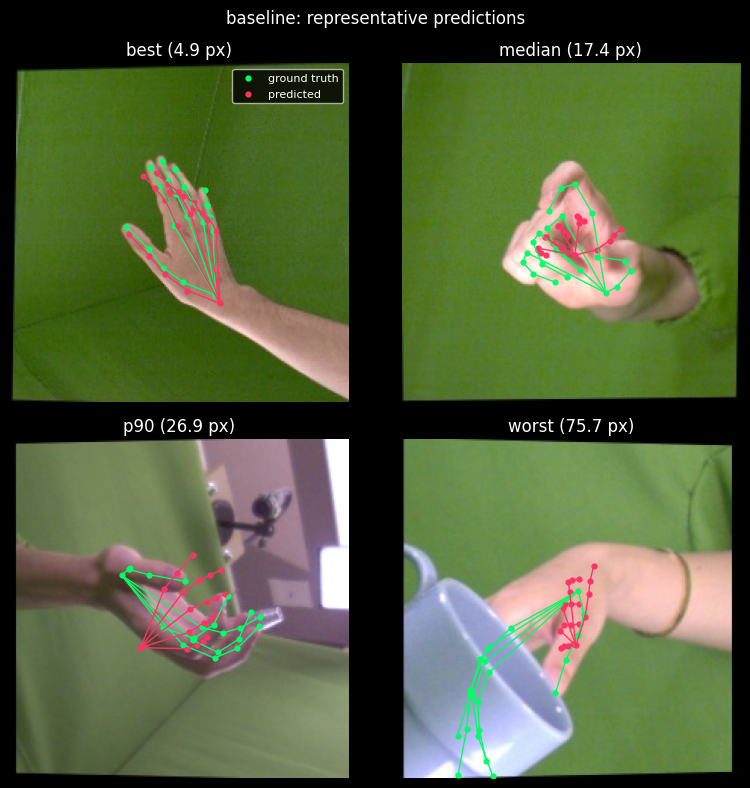

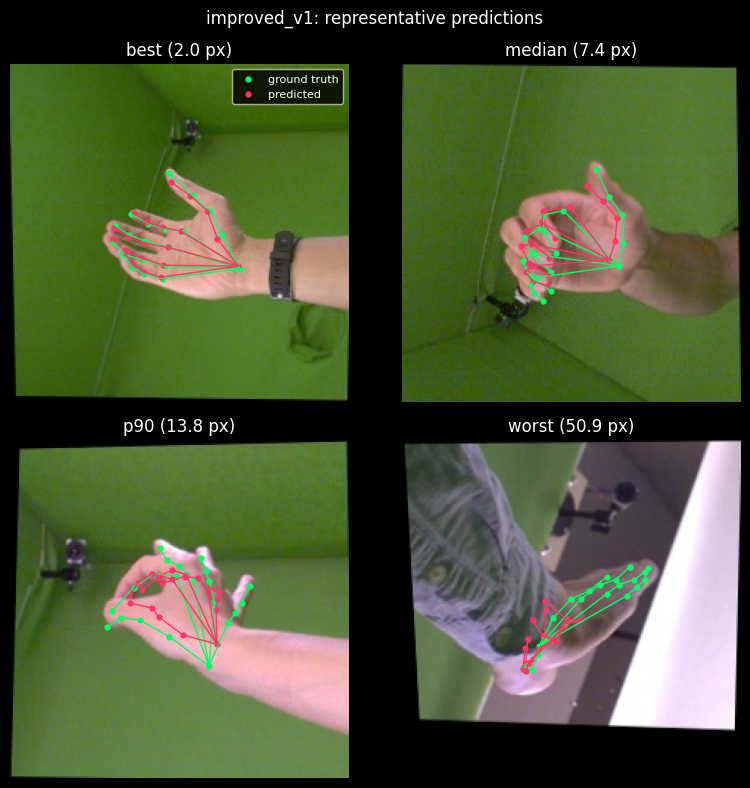

In [20]:
for run in RUNS:
    eval_payload = json.loads(
        (project_root / 'artifacts' / run / 'evaluation.json').read_text()
    )
    indices = eval_payload['metrics']['representative_indices']

    model = keras.models.load_model(
        str(project_root / 'models' / run / 'best.keras')
    )
    if len(model.output_shape) == 4:
        model = wrap_with_keypoint_decoder(model, input_size=224)

    sample_ids = np.array([val_idx[indices[label]] for label in LABELS])
    images, gt = dataset.load_batch(
        sample_ids, image_size=(224, 224), flatten_keypoints=False
    )
    preds = np.asarray(model.predict(images, verbose=0)).reshape(-1, 21, 2)

    errors = sample_mpke(preds, gt)
    titles = [f'{label} ({err:.1f} px)' for label, err in zip(LABELS, errors)]

    fig = prediction_grid(
        images, gt, preds,
        titles=titles,
        ncols=2,
        suptitle=f'{run}: representative predictions',
    )
    plt.show()